In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [49]:
df=pd.read_csv(r"D:\columns deleted.csv")
df

,S. No.,State/ UT,Required - allocated doc phcs,Sanctioned - alloc phcs,In Position - alloc phcs,Vacant -alloc phcs,Shortfall - [R-P] alloc phcs,Required - assist female phcs,Sanctioned - [S] assist female phcs,In Position - [P] assist female phcs,...,Primary Health Centres functioning at the end of - Tenth Plan - [2002-07],Primary Health Centres functioning at the end of - Eleventh Plan - [2007-12],"Primary Health Centres functioning at the end of - Twelth Plan (As on 31st March, 2017) - [2012-17]",Sub Centres functioning at the end of - Sixth Plan - [1981-85],Sub Centres functioning at the end of - Seventh Plan - [1985-90],Sub Centres functioning at the end of - Eigth Plan - [1992-97],Sub Centres functioning at the end of - Ninth Plan - [1997-2002],Sub Centres functioning at the end of - Tenth Plan - [2002-07],Sub Centres functioning at the end of - Eleventh Plan - [2007-12],"Sub Centres functioning at the end of - Twelth Plan - [2012-17] (As on 31st March, 2017)"
0,1,Andhra Pradesh,1147,1952.0,1644,308.0,NaN,1147,1264.0,1143,...,1570.0,1624.0,1147,6129.0,7894.0,10568.0,10568.0,12522.0,12522.0,7458
1,2,Arunachal Pradesh,143,NaN,122,NaN,21.0,143,NaN,6,...,85.0,97.0,143,55.0,155.0,223.0,273.0,379.0,286.0,312
2,3,Assam,1014,NaN,1048,NaN,NaN,1014,379.0,308,...,610.0,975.0,1014,1711.0,5109.0,5109.0,5109.0,5109.0,4604.0,4621
3,4,Bihar,1899,2078.0,1786,292.0,113.0,1899,850.0,95,...,1648.0,1863.0,1899,8299.0,14799.0,14799.0,14799.0,8909.0,9696.0,9949
4,5,Chhattisgarh,785,798.0,341,457.0,444.0,785,800.0,640,...,518.0,755.0,785,NaN,NaN,NaN,NaN,4692.0,5111.0,5186
5,6,Goa,24,48.0,56,NaN,NaN,24,16.0,9,...,19.0,19.0,24,156.0,166.0,172.0,172.0,172.0,205.0,214
6,7,Gujarat,1392,1769.0,1229,540.0,163.0,1392,1771.0,1218,...,1073.0,1158.0,1392,4869.0,6834.0,7274.0,7274.0,7274.0,7274.0,9082
7,8,Haryana,366,687.0,429,258.0,NaN,366,337.0,273,...,411.0,447.0,366,1591.0,2299.0,2299.0,2299.0,2433.0,2520.0,2589
8,9,Himachal Pradesh,538,636.0,492,144.0,46.0,538,146.0,0,...,443.0,472.0,538,1299.0,1851.0,1980.0,2069.0,2071.0,2065.0,2083
9,10,Jammu & Kashmir,637,1347.0,704,643.0,NaN,637,154.0,99,...,374.0,396.0,637,609.0,1460.0,1700.0,1700.0,1888.0,1907.0,2967


In [50]:
df.info

<bound method DataFrame.info of               S. No.             State/ UT  Required - allocated doc phcs  \
0                  1        Andhra Pradesh                           1147   
1                  2     Arunachal Pradesh                            143   
2                  3                 Assam                           1014   
3                  4                 Bihar                           1899   
4                  5          Chhattisgarh                            785   
5                  6                   Goa                             24   
6                  7               Gujarat                           1392   
7                  8               Haryana                            366   
8                  9      Himachal Pradesh                            538   
9                 10       Jammu & Kashmir                            637   
10                11             Jharkhand                            297   
11                12             Karnataka  

In [51]:
df.shape

(37, 142)

In [52]:
df.columns

Index(['S. No.', 'State/ UT', 'Required - allocated doc phcs',
       'Sanctioned - alloc phcs', 'In Position - alloc phcs',
       'Vacant -alloc phcs', 'Shortfall - [R-P] alloc phcs',
       'Required - assist female phcs', 'Sanctioned - [S] assist female phcs',
       'In Position - [P] assist female phcs',
       ...
       'Primary Health Centres functioning at the end of - Tenth Plan - [2002-07]',
       'Primary Health Centres functioning at the end of - Eleventh Plan - [2007-12]',
       'Primary Health Centres functioning at the end of - Twelth Plan (As on 31st March, 2017) - [2012-17]',
       'Sub Centres functioning at the end of - Sixth Plan - [1981-85]',
       'Sub Centres functioning at the end of - Seventh Plan - [1985-90]',
       'Sub Centres functioning at the end of - Eigth Plan - [1992-97]',
       'Sub Centres functioning at the end of - Ninth Plan - [1997-2002]',
       'Sub Centres functioning at the end of - Tenth Plan - [2002-07]',
       'Sub Centres functio

In [53]:
null_counts = df.isnull().sum()

# Display the count of null values for each column
print(null_counts)

S. No.                                                                                      0
State/ UT                                                                                   0
Required - allocated doc phcs                                                               0
Sanctioned - alloc phcs                                                                     3
In Position - alloc phcs                                                                    0
                                                                                           ..
Sub Centres functioning at the end of - Eigth Plan - [1992-97]                              4
Sub Centres functioning at the end of - Ninth Plan - [1997-2002]                            4
Sub Centres functioning at the end of - Tenth Plan - [2002-07]                              1
Sub Centres functioning at the end of - Eleventh Plan - [2007-12]                           1
Sub Centres functioning at the end of - Twelth Plan - [2012-

In [54]:
null_columns = null_counts[null_counts > 0]

# Display columns with null values and their counts
print(null_columns)

Sanctioned - alloc phcs                                               3
Vacant -alloc phcs                                                   10
Shortfall - [R-P] alloc phcs                                         22
Sanctioned - [S] assist female phcs                                   1
Vacant - [S-P] assist female phcs                                     6
                                                                     ..
Sub Centres functioning at the end of - Seventh Plan - [1985-90]      4
Sub Centres functioning at the end of - Eigth Plan - [1992-97]        4
Sub Centres functioning at the end of - Ninth Plan - [1997-2002]      4
Sub Centres functioning at the end of - Tenth Plan - [2002-07]        1
Sub Centres functioning at the end of - Eleventh Plan - [2007-12]     1
Length: 64, dtype: int64


In [55]:
df= df.fillna(df.mean())


# Verify that there are no more null values
null_counts_filled = df.isnull().sum()
print("\nNull values in each column after filling:\n", null_counts_filled)


Null values in each column after filling:
 S. No.                                                                                      0
State/ UT                                                                                   0
Required - allocated doc phcs                                                               0
Sanctioned - alloc phcs                                                                     0
In Position - alloc phcs                                                                    0
                                                                                           ..
Sub Centres functioning at the end of - Eigth Plan - [1992-97]                              0
Sub Centres functioning at the end of - Ninth Plan - [1997-2002]                            0
Sub Centres functioning at the end of - Tenth Plan - [2002-07]                              0
Sub Centres functioning at the end of - Eleventh Plan - [2007-12]                           0
Sub Centres func

C:\Users\ARJUN\AppData\Local\Temp\ipykernel_15416\2293936557.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df= df.fillna(df.mean())


In [56]:
df.head()

,S. No.,State/ UT,Required - allocated doc phcs,Sanctioned - alloc phcs,In Position - alloc phcs,Vacant -alloc phcs,Shortfall - [R-P] alloc phcs,Required - assist female phcs,Sanctioned - [S] assist female phcs,In Position - [P] assist female phcs,...,Primary Health Centres functioning at the end of - Tenth Plan - [2002-07],Primary Health Centres functioning at the end of - Eleventh Plan - [2007-12],"Primary Health Centres functioning at the end of - Twelth Plan (As on 31st March, 2017) - [2012-17]",Sub Centres functioning at the end of - Sixth Plan - [1981-85],Sub Centres functioning at the end of - Seventh Plan - [1985-90],Sub Centres functioning at the end of - Eigth Plan - [1992-97],Sub Centres functioning at the end of - Ninth Plan - [1997-2002],Sub Centres functioning at the end of - Tenth Plan - [2002-07],Sub Centres functioning at the end of - Eleventh Plan - [2007-12],"Sub Centres functioning at the end of - Twelth Plan - [2012-17] (As on 31st March, 2017)"
0,1,Andhra Pradesh,1147,1952.000000,1644,308.000000,403.6,1147,1264.000000,1143,...,1570.0,1624.0,1147,6129.00000,7894.000000,10568.000000,10568.000000,12522.0,12522.0,7458
1,2,Arunachal Pradesh,143,1998.117647,122,613.777778,21.0,143,1208.222222,6,...,85.0,97.0,143,55.00000,155.000000,223.000000,273.000000,379.0,286.0,312
2,3,Assam,1014,1998.117647,1048,613.777778,403.6,1014,379.000000,308,...,610.0,975.0,1014,1711.00000,5109.000000,5109.000000,5109.000000,5109.0,4604.0,4621
3,4,Bihar,1899,2078.000000,1786,292.000000,113.0,1899,850.000000,95,...,1648.0,1863.0,1899,8299.00000,14799.000000,14799.000000,14799.000000,8909.0,9696.0,9949
4,5,Chhattisgarh,785,798.000000,341,457.000000,444.0,785,800.000000,640,...,518.0,755.0,785,5113.69697,7888.787879,8258.060606,8321.878788,4692.0,5111.0,5186


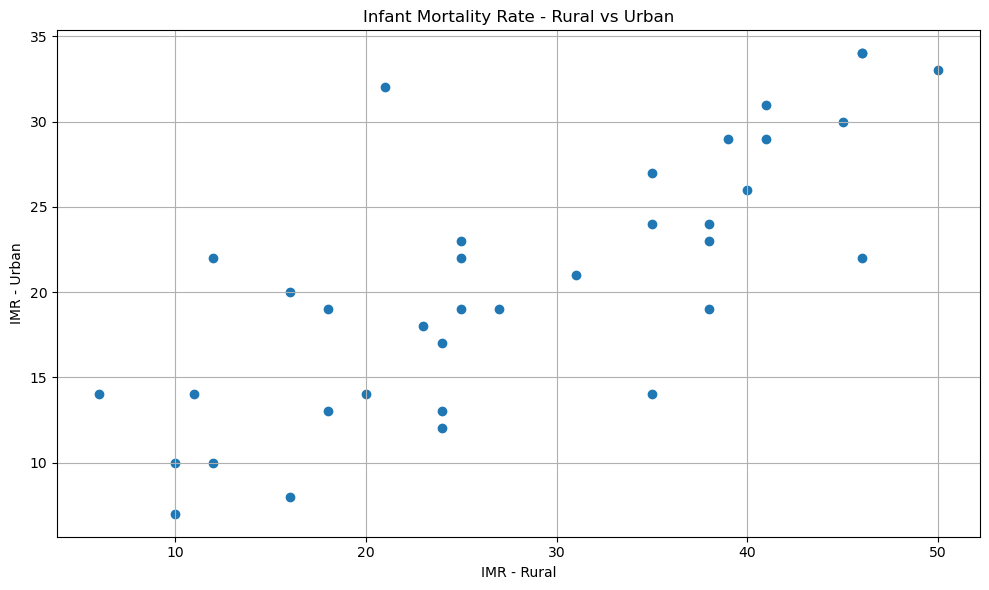

In [57]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['Infant Mortality Rate [IMR] - Rural'], df_filtered['Infant Mortality Rate [IMR] - Urban'])
plt.title('Infant Mortality Rate - Rural vs Urban')
plt.xlabel('IMR - Rural')
plt.ylabel('IMR - Urban')
plt.grid(True)
plt.tight_layout()
plt.show()


In [58]:
df_filtered = df[df['State/ UT'] != 'All India/ Total']

# Find states with the least number of CHCs and PHCs functioning
least_chcs_states = df_filtered.nsmallest(10, 'Number of CHCs Functioning')['State/ UT']
least_phcs_states = df_filtered.nsmallest(10, 'Number of PHCs Functioning')['State/ UT']

# Filter the DataFrame to include only the least states
df_least_chcs = df_filtered[df_filtered['State/ UT'].isin(least_chcs_states)]
df_least_phcs = df_filtered[df_filtered['State/ UT'].isin(least_phcs_states)]

# Create subplots for CHCs and PHCs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Pie chart for CHCs
ax1.pie(df_least_chcs['Number of CHCs Functioning'], labels=df_least_chcs['State/ UT'], autopct='%1.1f%%', startangle=140)
ax1.set_title('States with Least Number of CHCs Functioning')

# Pie chart for PHCs
ax2.pie(df_least_phcs['Number of PHCs Functioning'], labels=df_least_phcs['State/ UT'], autopct='%1.1f%%', startangle=140)
ax2.set_title('States with Least Number of PHCs Functioning')

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the charts
plt.show()

KeyError: 'Number of CHCs Functioning'

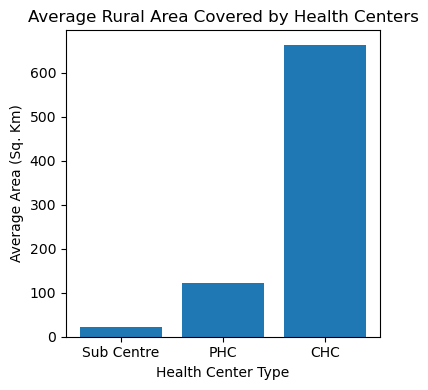

In [59]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

# Plotting bar chart for average rural area covered by a Sub Centre, PHC, and CHC
plt.figure(figsize=(4, 4))
plt.bar(['Sub Centre', 'PHC', 'CHC'],
        [df_filtered['Average Rural Area [Sq. Km.] covered by a sub Centre'].mean(),
         df_filtered['Average Rural Area [Sq. Km.] covered by a PHC'].mean(),
         df_filtered['Average Rural Area [Sq. Km.] covered by a CHC'].mean()])
plt.title('Average Rural Area Covered by Health Centers')
plt.xlabel('Health Center Type')
plt.ylabel('Average Area (Sq. Km)')
plt.tight_layout()
plt.show()


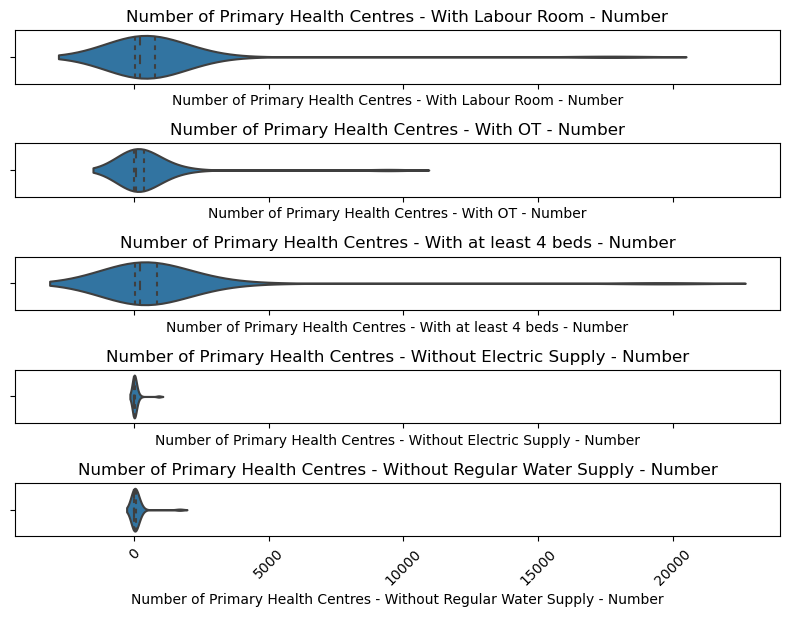

In [60]:
columns_to_plot = [
    'Number of Primary Health Centres - With Labour Room - Number',
    'Number of Primary Health Centres - With OT - Number',
    'Number of Primary Health Centres - With at least 4 beds - Number',
    'Number of Primary Health Centres - Without Electric Supply - Number',
    'Number of Primary Health Centres - Without Regular Water Supply - Number'
]

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(columns_to_plot), figsize=(8, 6), sharex=True)

# Plot violin plots for each column
for i, col in enumerate(columns_to_plot):
    sns.violinplot(x=df[col], ax=axes[i], inner='quartile')
    axes[i].set_title(col)

# Adjust layout
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels if necessary
plt.show()

<Figure size 1200x800 with 0 Axes>

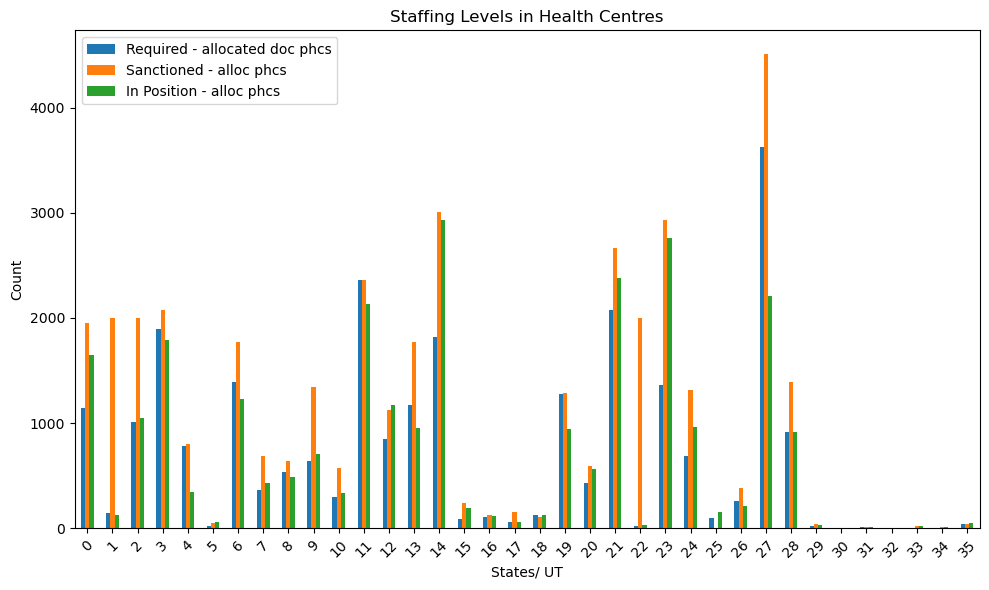

In [61]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

plt.figure(figsize=(12, 8))
df_staffing = df_filtered[['Required - allocated doc phcs', 'Sanctioned - alloc phcs', 'In Position - alloc phcs']]
df_staffing.plot(kind='bar', figsize=(10, 6))
plt.title('Staffing Levels in Health Centres')
plt.xlabel('States/ UT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

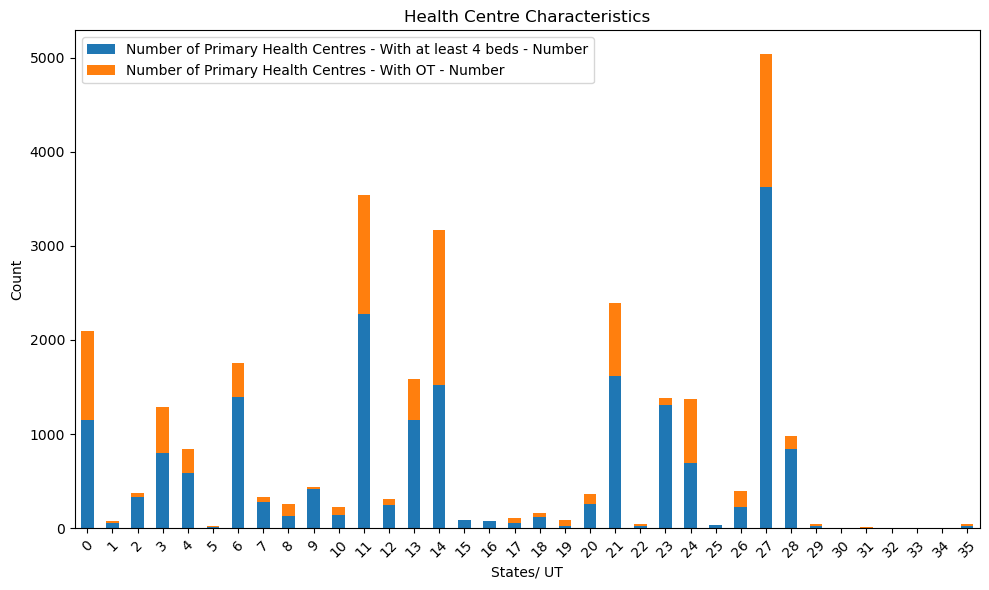

In [62]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

# Select columns of interest
characteristics_columns = ['Number of Primary Health Centres - With at least 4 beds - Number',
                           'Number of Primary Health Centres - With OT - Number']

# Plotting stacked bar chart for selected columns
plt.figure(figsize=(12, 8))
df_filtered[characteristics_columns].plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Health Centre Characteristics')
plt.xlabel('States/ UT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


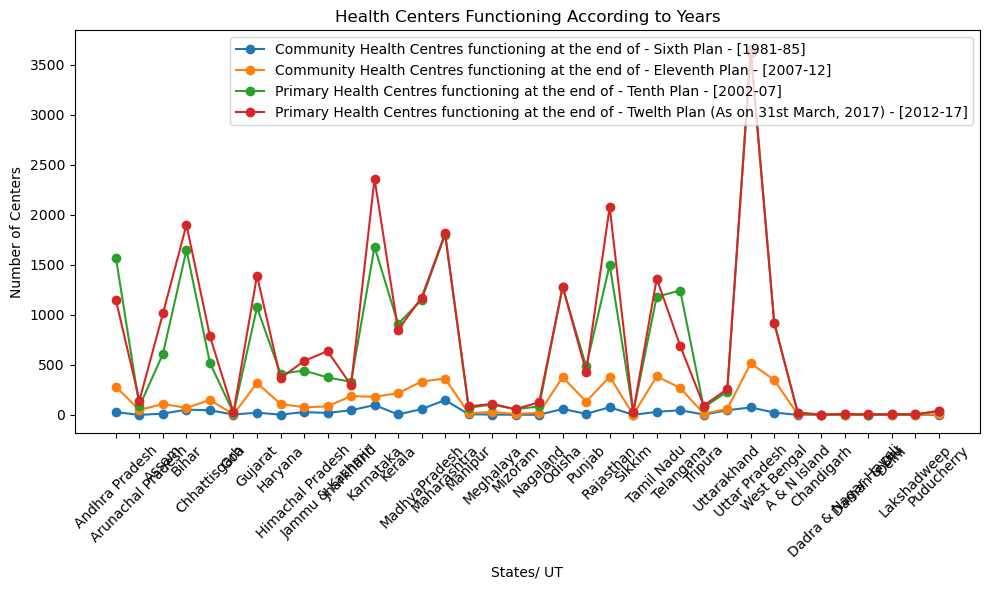

In [63]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

# Selecting columns for health centers functioning according to different plans
plan_columns = [
    'Community Health Centres functioning at the end of - Sixth Plan - [1981-85]',
    'Community Health Centres functioning at the end of - Eleventh Plan - [2007-12]',
    'Primary Health Centres functioning at the end of - Tenth Plan - [2002-07]',
    'Primary Health Centres functioning at the end of - Twelth Plan (As on 31st March, 2017) - [2012-17]'
]

# Plotting line chart for health centers functioning according to years
plt.figure(figsize=(10, 6))
for col in plan_columns:
    plt.plot(df_filtered['State/ UT'], df_filtered[col], marker='o', label=col)

plt.title('Health Centers Functioning According to Years')
plt.xlabel('States/ UT')
plt.ylabel('Number of Centers')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

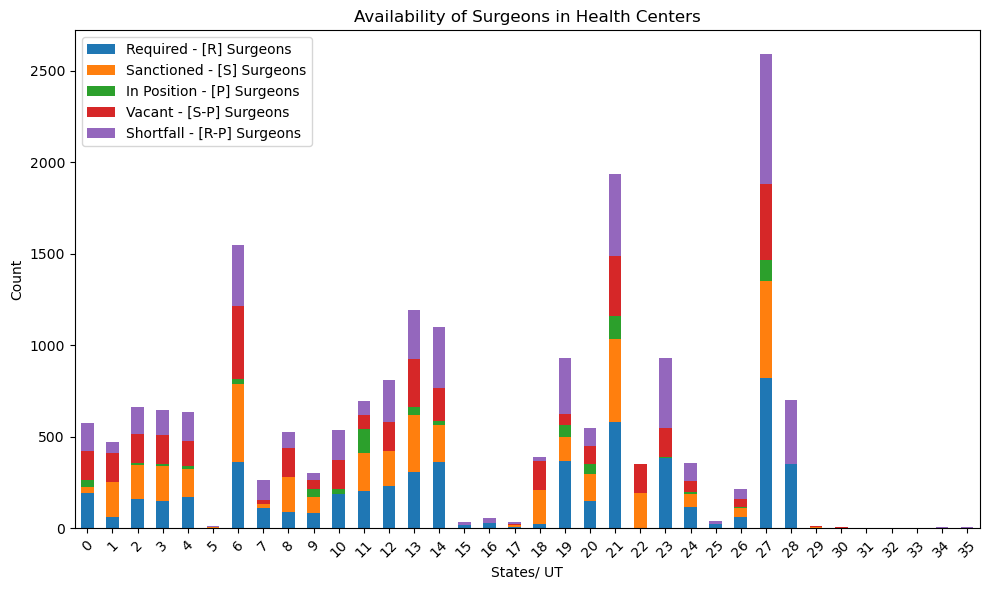

In [64]:

df_filtered = df[df['State/ UT'] != 'All India/ Total']

# Selecting columns related to surgeons
surgeon_columns = [
    'Required - [R] Surgeons',
    'Sanctioned - [S] Surgeons',
    'In Position - [P] Surgeons',
    'Vacant - [S-P] Surgeons',
    'Shortfall - [R-P] Surgeons'
]

# Plotting stacked bar chart for surgeons
plt.figure(figsize=(12, 8))
df_filtered[surgeon_columns].plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Availability of Surgeons in Health Centers')
plt.xlabel('States/ UT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


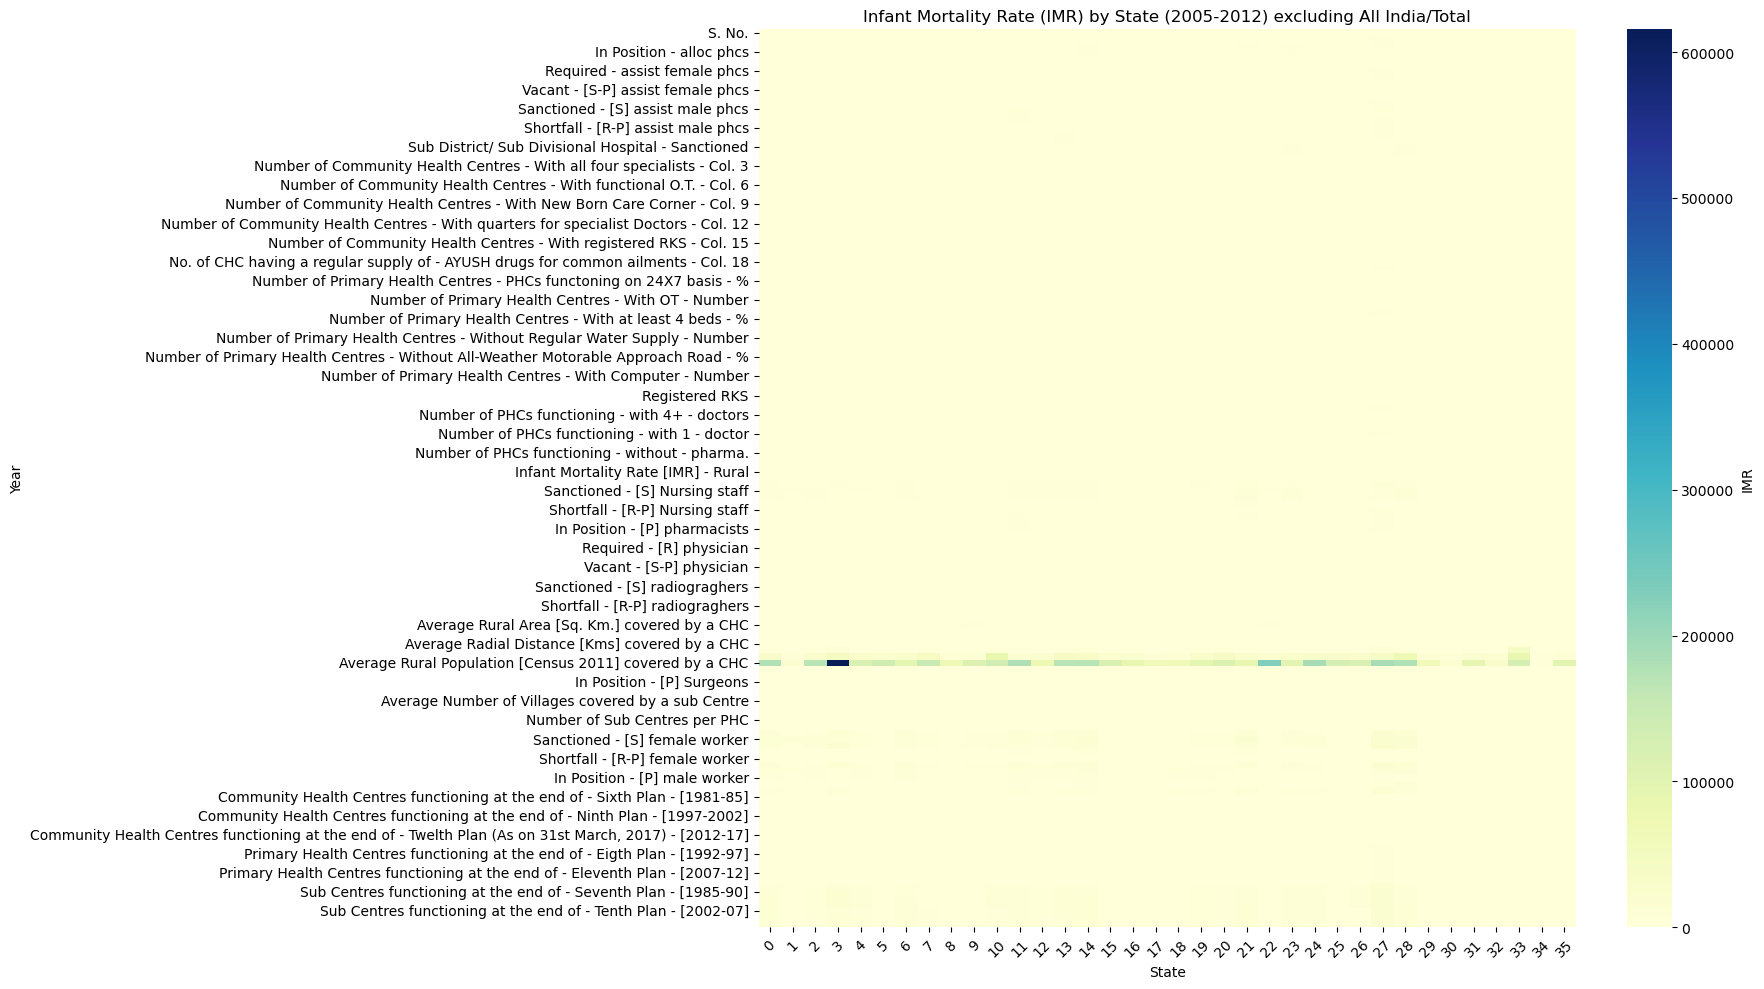

In [65]:


# Assuming `df` is your DataFrame with IMR values by State and Year
# Filter out "All India/ Total" and drop 'State/ UT' column
state_data_filtered = df[df['State/ UT'] != 'All India/ Total'].drop(columns=['State/ UT'])

# Convert data to numeric
state_data_filtered = state_data_filtered.apply(pd.to_numeric, errors='coerce')

# Transpose the DataFrame
state_data_transposed = state_data_filtered.T

plt.figure(figsize=(18, 10))
sns.heatmap(state_data_transposed, cmap="YlGnBu", cbar_kws={'label': 'IMR'})
plt.title('Infant Mortality Rate (IMR) by State (2005-2012) excluding All India/Total')
plt.xlabel('State')
plt.ylabel('Year')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)   # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()


In [66]:
columns_to_keep = [
    'State/ UT',
    'Sanctioned - alloc phcs', 'In Position - alloc phcs', 
    'Sanctioned - [S] assist female phcs','In Position - [P]assist male phcs', 
    'District Hospital - Sanctioned', 'District Hospital - In Position', 
    'Sub District/ Sub Divisional Hospital - Sanctioned', 'Sub District/ Sub Divisional Hospital - In Position', 
    'Number of CHCs Functioning',  
    'Number of Community Health Centres - With functional Laboratory', 
    'Number of Community Health Centres - With functional O.T.',
    'Number of Community Health Centres - With functional Labor Room',  
    'Number of Community Health Centres - With New Born Care Corner',   
    'Number of Community Health Centres - With functional X-Ray machine',
    'Number of Community Health Centres - With registered RKS', 
    'Number of Community Health Centres - Functioning as per IPHS norms', 
    'Number of PHCs Functioning', 
    'Number of Primary Health Centres - PHCs functoning on 24X7 basis - Number', 
    'Number of Primary Health Centres - With Labour Room - Number', 
    'Number of Primary Health Centres - With OT - Number',  
    'Number of Primary Health Centres - Without Regular Water Supply - Number', 
    'Registered RKS', 
    'No. of PHCs Functioning as per IPHS norms', 
    'Total PHCs functioning', 
    'Number of PHCs functioning - with 4+ - doctors',  
    'Number of PHCs functioning - with 1 - doctor', 
    'Number of PHCs functioning - without - doctor', 
    'Number of PHCs functioning - with - lady - doctor',
    'Infant Mortality Rate [IMR] - Total'
]

# Drop columns not in columns_to_keep
df = df.drop(columns=df.columns.difference(columns_to_keep), axis=1)


In [87]:


# Separate features (X) and target (y)
X = df.drop(columns=['Infant Mortality Rate [IMR] - Total'])
y = df['Infant Mortality Rate [IMR] - Total']
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X['State/ UT'] = label_encoder.fit_transform(X['State/ UT'])

# Train-test split with test size 0.2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [88]:
X_train

,State/ UT,Sanctioned - alloc phcs,In Position - alloc phcs,Sanctioned - [S] assist female phcs,In Position - [P]assist male phcs,District Hospital - Sanctioned,District Hospital - In Position,Sub District/ Sub Divisional Hospital - Sanctioned,Sub District/ Sub Divisional Hospital - In Position,Number of PHCs Functioning,...,Number of Primary Health Centres - With Labour Room - Number,Number of Primary Health Centres - With OT - Number,Number of Primary Health Centres - Without Regular Water Supply - Number,Registered RKS,No. of PHCs Functioning as per IPHS norms,Total PHCs functioning,Number of PHCs functioning - with 4+ - doctors,Number of PHCs functioning - with 1 - doctor,Number of PHCs functioning - without - doctor,Number of PHCs functioning - with - lady - doctor
34,19,8.000000,8,1.000000,0,35.0,25.0,8.000000,8.000000,4,...,4,4,0,4,4.0,4,2,0,0,3
25,33,0.000000,156,0.000000,23,84.0,307.0,64.000000,113.000000,93,...,73,0,16,92,66.0,93,23,9,0,43
12,18,1120.000000,1169,13.000000,2186,87.0,502.0,488.000000,624.000000,849,...,62,60,0,849,0.0,849,1,694,0,460
1,3,1998.117647,122,1208.222222,81,1518.0,381.0,1164.466667,809.272727,143,...,72,20,24,117,0.0,143,3,81,40,36
28,36,1390.000000,918,200.000000,73,1597.0,1343.0,5267.000000,2877.000000,914,...,909,129,30,914,308.0,914,2,592,139,112
19,26,1285.000000,940,1162.000000,0,1604.0,1185.0,357.000000,326.000000,1280,...,584,59,154,1279,0.0,1280,0,520,86,507
26,35,386.000000,215,192.000000,13,377.0,258.0,218.000000,158.000000,257,...,164,171,14,237,69.0,257,3,122,63,58
23,31,2927.000000,2759,1362.000000,1036,1649.0,1176.0,2817.000000,2530.000000,1362,...,1299,71,0,1362,1271.0,1362,204,197,0,908
27,34,4509.000000,2209,3781.000000,954,2671.0,2108.0,0.000000,0.000000,3621,...,1978,1416,270,460,170.0,3621,26,2772,0,319
10,16,569.000000,331,327.000000,33,887.0,501.0,152.000000,60.000000,297,...,225,85,139,297,0.0,297,1,147,108,37


In [89]:
y_train

34    19
25    24
12    10
1     36
28    25
19    44
26    38
23    17
27    43
10    29
4     39
6     30
3     38
30    14
5      8
24    31
20    21
36    34
21    41
32    19
17    27
2     44
7     33
35    10
11    24
18    12
22    16
8     25
15    11
Name: Infant Mortality Rate [IMR] - Total, dtype: int64

In [90]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd


# Assuming 'Madhya Pradesh' is in a column named 'state'

# Assuming 'State/ UT' is a categorical variable, and other categorical columns might exist
categorical_cols = ['State/ UT']  # Add other categorical columns if needed

# One-hot encode categorical columns
ct = ColumnTransformer(
    [('onehot', OneHotEncoder(sparse=False, drop='first'), categorical_cols)],
    remainder='passthrough'
)
X_encoded = ct.fit_transform(X)

# Train-test split with encoded data
X_train_enc, X_test_enc, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize models
rf_model = RandomForestRegressor(random_state=42)
dt_model = DecisionTreeRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit models
rf_model.fit(X_train_enc, y_train)
dt_model.fit(X_train_enc, y_train)
xgb_model.fit(X_train_enc, y_train)
history=lr_model.fit(X_train_enc, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_enc)
dt_pred = dt_model.predict(X_test_enc)
xgb_pred = xgb_model.predict(X_test_enc)
lr_pred_class = lr_model.predict(X_test_enc)

# Metrics for regression models
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# Metrics for Logistic Regression (classification)
threshold = y_train.mean()
y_test_binary = (y_test > threshold).astype(int)
lr_pred_class_binary = (lr_pred_class > threshold).astype(int)

lr_accuracy = accuracy_score(y_test_binary, lr_pred_class_binary)
lr_precision = precision_score(y_test_binary, lr_pred_class_binary)
lr_recall = recall_score(y_test_binary, lr_pred_class_binary)
lr_f1 = f1_score(y_test_binary, lr_pred_class_binary)

# Displaying results
print("Random Forest Metrics:")
print(f"Mean Squared Error: {rf_mse}")
print(f"R^2 Score: {rf_r2}")
print()

print("Decision Tree Metrics:")
print(f"Mean Squared Error: {dt_mse}")
print(f"R^2 Score: {dt_r2}")
print()

print("XGBoost Metrics:")
print(f"Mean Squared Error: {xgb_mse}")
print(f"R^2 Score: {xgb_r2}")
print()

print("Logistic Regression Metrics:")
print(f"Accuracy: {lr_accuracy}")
print(f"Precision: {lr_precision}")
print(f"Recall: {lr_recall}")
print(f"F1-score: {lr_f1}")


Random Forest Metrics:
Mean Squared Error: 67.55423749999997
R^2 Score: 0.49249076182650564

Decision Tree Metrics:
Mean Squared Error: 160.25
R^2 Score: -0.20389717102946348

XGBoost Metrics:
Mean Squared Error: 67.86753951994888
R^2 Score: 0.4901370431650748

Logistic Regression Metrics:
Accuracy: 0.75
Precision: 1.0
Recall: 0.6
F1-score: 0.7499999999999999


C:\Users\ARJUN\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


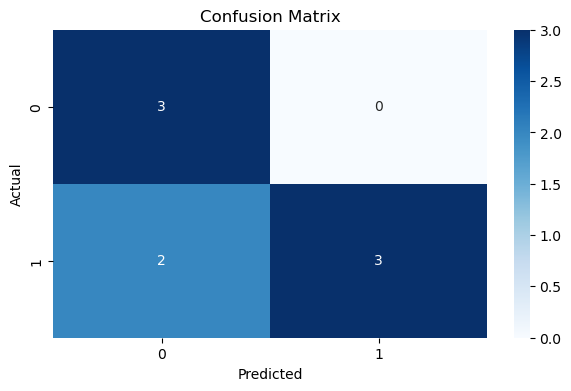

In [91]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
# Generate binary predictions based on the threshold
lr_pred_class_binary = (lr_pred_class > threshold).astype(int)

# Plot confusion matrix
plot_confusion_matrix(y_test_binary, lr_pred_class_binary)


C:\Users\ARJUN\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: X has 21 features, but LogisticRegression is expecting 56 features as input.